In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

In [24]:
# Đọc file và xử lý lại thời gian

df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

df.head() # check xem data đã lòa được chưa, hiểu sơ cấu trúc
df.info()# kiểm tra số dòng, cột, các kiểu biến , có lỗi kiểu dữ liệu không
df['date_time'] = pd.to_datetime(df['date_time']) # dữ liệu cột date time phải là dạng thời gian , không phải text
df = df.sort_values('date_time') # săp xếp theo thời gian

print(df['date_time'].min(), "→", df['date_time'].max()) # xem khoảng thời gian data

# kiểm tra missing 
print(" Missing value: ")
print(df.isnull().sum())

# Check duplicate theo date_time
print("Kiểm tra trùng lặp theo date_time:  ")
print(df.duplicated(['date_time']).sum())

print("Thống kê mô tả traffic_volume: ")
df['traffic_volume'].describe() #

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 4.8 MB
2012-10-02 09:00:00 → 2018-09-30 23:00:00
 Missing value: 
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traf

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

# 2.2.2. Phân tích đặc điểm chuỗi thời gian

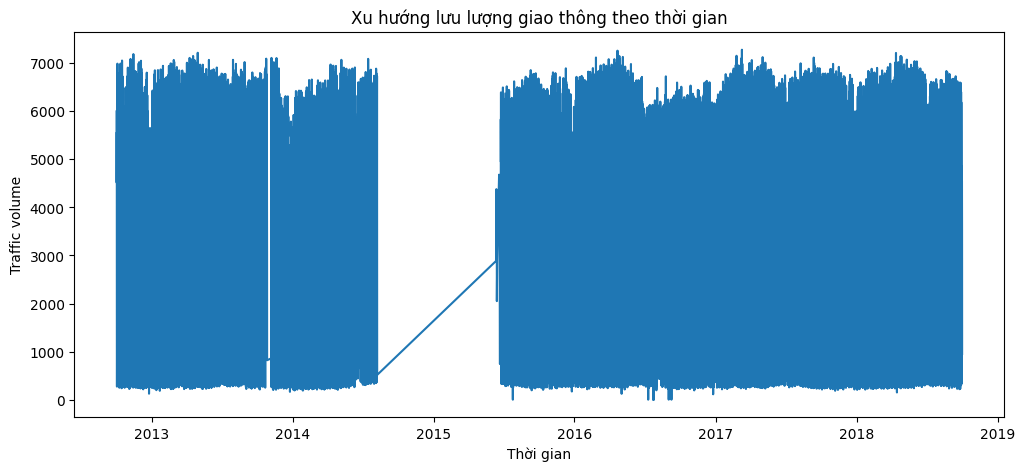

In [25]:
# --- Xu hướng theo thời gian (Trend)---

df_time = df.groupby('date_time')['traffic_volume'].mean().reset_index()
df_time = df_time.sort_values('date_time')

plt.figure(figsize=(12,5))
plt.plot(df_time['date_time'], df_time['traffic_volume'])
plt.title("Xu hướng lưu lượng giao thông theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("Traffic volume")
plt.show()

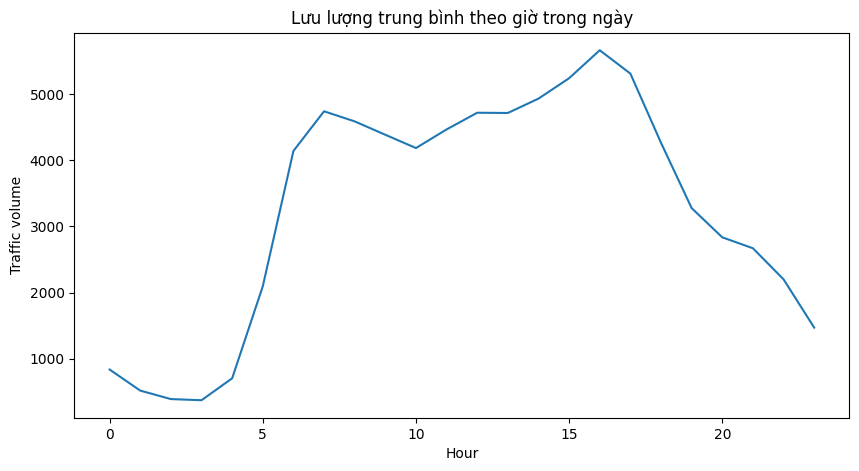

In [26]:
# Chu kỳ theo giờ trong ngày (QUAN TRỌNG NHẤT) ---

df['hour'] = pd.to_datetime(df['date_time']).dt.hour

hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values)
plt.title("Lưu lượng trung bình theo giờ trong ngày")
plt.xlabel("Hour")
plt.ylabel("Traffic volume")
plt.show()

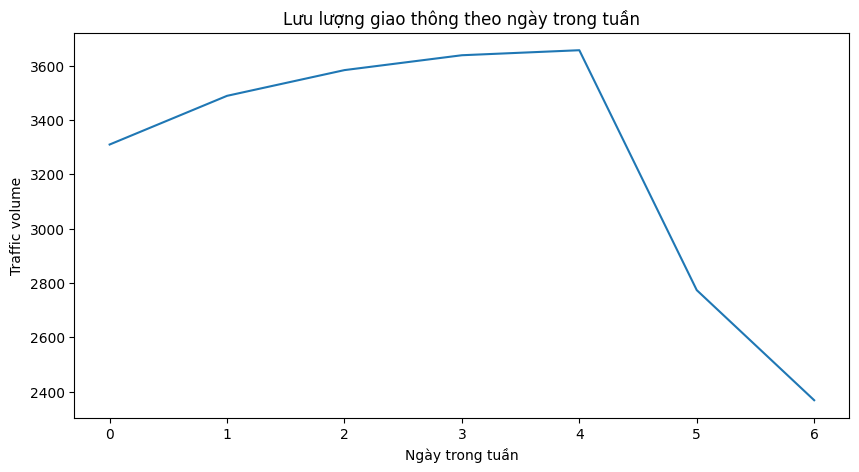

In [39]:
# Kiểm tra tính chu kỳ theo ngày trong tuần ---

df['day_of_week'] = pd.to_datetime(df['date_time']).dt.dayofweek

dow = df.groupby('dayofweek')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(dow.index, dow.values)
plt.title("Lưu lượng giao thông theo ngày trong tuần")
plt.xlabel("Ngày trong tuần")
plt.ylabel("Traffic volume")
plt.show()

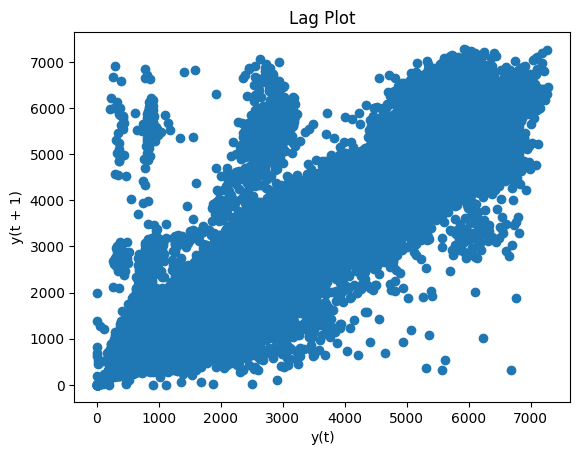

In [ ]:
#--- Lag plot (dependency)/ Biểu đồ tương quan trễ (lag plot) ---

lag_plot(df['traffic_volume'])
plt.title("Lag Plot")
plt.show()

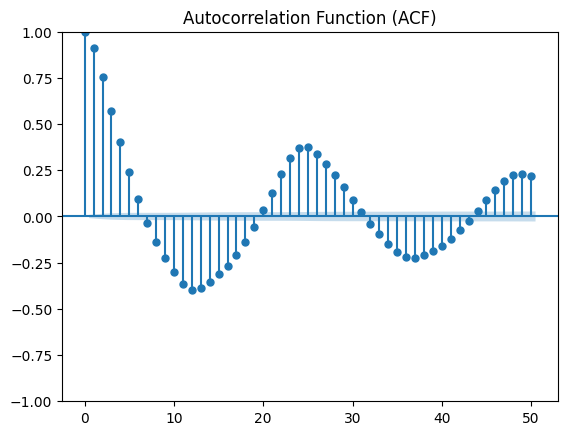

In [34]:
#--- Hàm tự tương quan (Autocorrelation Function)---

plot_acf(df['traffic_volume'], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

In [35]:
df['time_diff'] = df['date_time'].diff().dt.total_seconds()

df['time_diff'].value_counts().head()

time_diff
3600.0     37986
0.0         7629
7200.0      2192
10800.0      201
14400.0       59
Name: count, dtype: int64

# 2.2.3. Phân tích chế độ vận hành (regime)

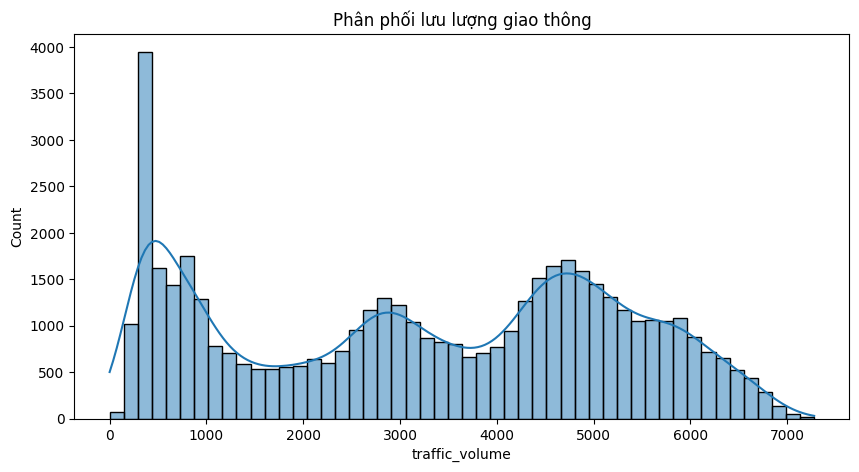

In [ ]:
# --- Phân phối lưu lượng giao thông---

plt.figure(figsize=(10,5))
sns.histplot(df['traffic_volume'], bins=50, kde=True)
plt.title("Phân phối lưu lượng giao thông")
plt.show()

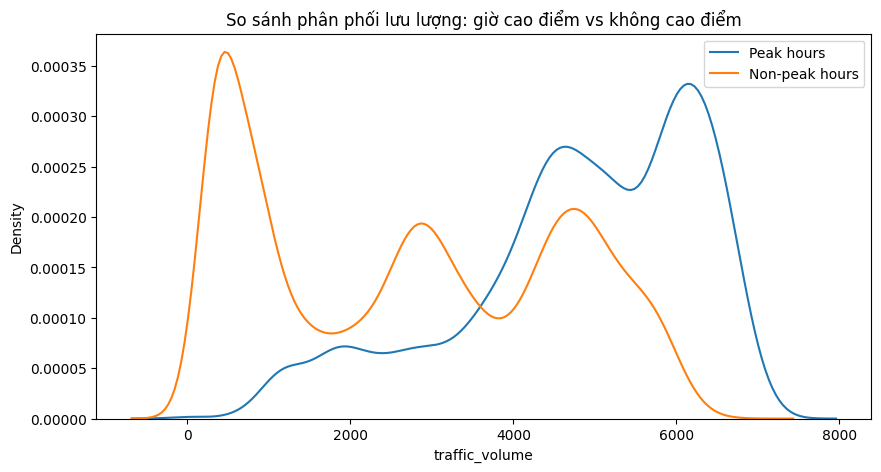

In [32]:
# --- So sánh giờ cao điểm và ngoài cao điểm ---

df['is_peak'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 18) else 0)

peak = df[df['is_peak'] == 1]['traffic_volume']
non_peak = df[df['is_peak'] == 0]['traffic_volume']

plt.figure(figsize=(10,5))
sns.kdeplot(peak, label="Peak hours")
sns.kdeplot(non_peak, label="Non-peak hours")
plt.legend()
plt.title("So sánh phân phối lưu lượng: giờ cao điểm vs không cao điểm")
plt.show()

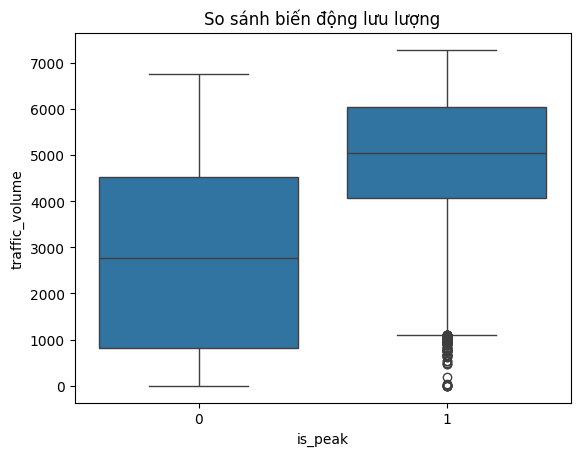

In [33]:
sns.boxplot(x='is_peak', y='traffic_volume', data=df)
plt.title("So sánh biến động lưu lượng")
plt.show()

# 2.2.4. Đặc điểm quan sát gián tiếp (hidden structure / unlabeled state)

In [37]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
hour                       0
dayofweek                  0
is_peak                    0
time_diff                  1
dtype: int64

In [38]:
df['traffic_volume'].nunique()

6704

In [ ]:

df[['traffic_volume','weather_main','weather_description']].head()

,traffic_volume,weather_main,weather_description
0,5545,Clouds,scattered clouds
1,4516,Clouds,broken clouds
2,4767,Clouds,overcast clouds
3,5026,Clouds,overcast clouds
4,4918,Clouds,broken clouds
